In [4]:
import numpy as np
import pennylane as qml

In [ ]:
# queremos encontrar o estado |11> 

n_qubits = 3 

dev = qml.device("default.qubit", wires=n_qubits)


@qml.qnode(dev)
def grover_2qubits():
    #criar sobreposiçao nos qubits da base de dados
    for q in range(n_qubits - 1):
        qml.Hadamard(wires=q)
    #criar ancilla no estado |->
    qml.PauliX(wires=n_qubits-1)
    qml.Hadamard(wires=n_qubits-1)

    #oracle p/ encontrar |11> 
    qml.Toffoli(wires=[0,1,2])

    #difusor 
    for q in range(n_qubits - 1):
        qml.Hadamard(wires=q)
        qml.PauliX(wires=q)
    
    qml.CZ(wires=[0,1])

    for q in range(n_qubits - 1):
        qml.PauliX(wires=q)
        qml.Hadamard(wires=q)
    
    return qml.probs(wires=[0,1])
    






(<Figure size 1100x400 with 1 Axes>, <Axes: >)

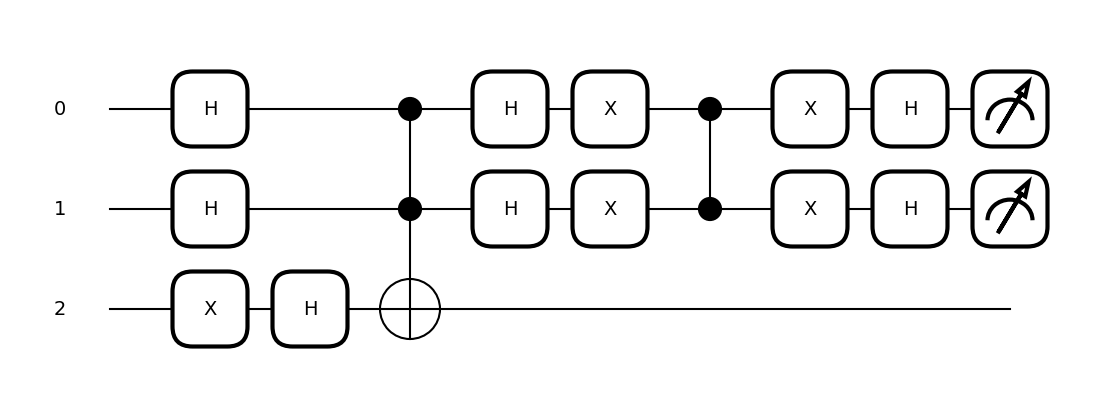

In [11]:
qml.draw_mpl(grover_2qubits)()

In [10]:
grover_2qubits()

array([0., 0., 0., 1.])

In [ ]:
# queremos encontrar o estado |11> 

n_qubits = 3

dev = qml.device("default.qubit", wires=n_qubits)


@qml.qnode(dev)
def grover_2qubits(iterations):
    #criar sobreposiçao nos qubits da base de dados
    for q in range(n_qubits - 1):
        qml.Hadamard(wires=q)
    #criar ancilla no estado |->
    qml.PauliX(wires=n_qubits-1)
    qml.Hadamard(wires=n_qubits-1)

    for j in range(iterations):
        #oracle p/ encontrar |111> 
        qml.ctrl(qml.PauliX , range(n_qubits-1))(n_qubits-1) 

        #difusor 
        for q in range(n_qubits - 1):
            qml.Hadamard(wires=q)
            qml.PauliX(wires=q)
        
        qml.ctrl(qml.PauliZ , range(n_qubits-2))(n_qubits-2) 

        for q in range(n_qubits - 1):
            qml.PauliX(wires=q)
            qml.Hadamard(wires=q)
    
    return qml.probs(wires=range(n_qubits-1))
    






(<Figure size 1700x400 with 1 Axes>, <Axes: >)

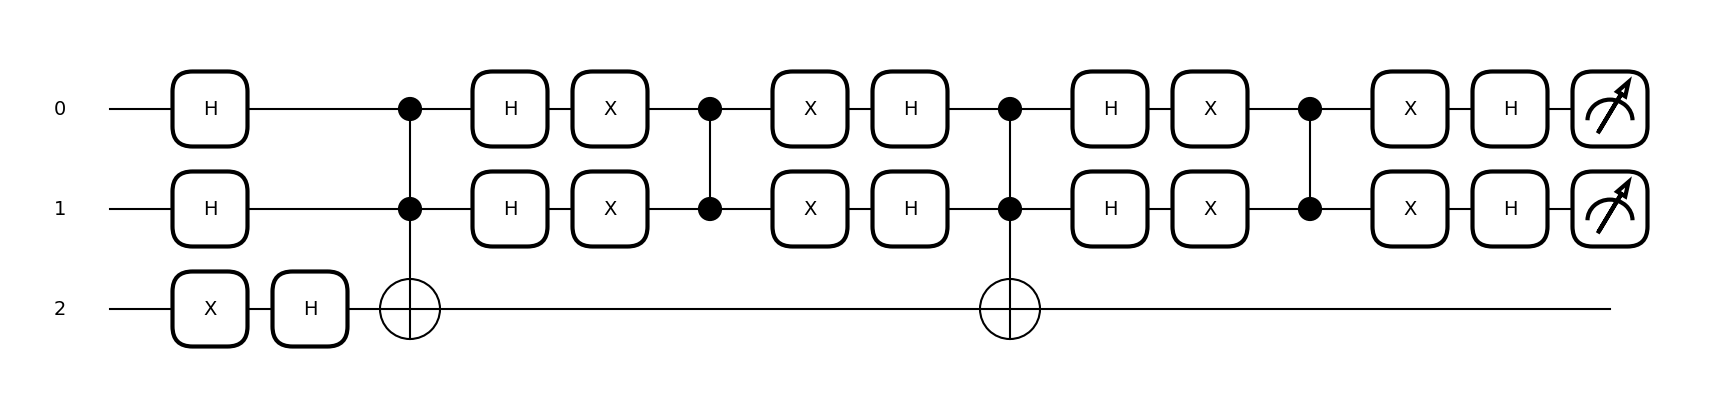

In [45]:

iterations = 2
qml.draw_mpl(grover_2qubits)(iterations)

In [46]:
grover_2qubits(iterations)

array([0.25, 0.25, 0.25, 0.25])

In [2]:
import pennylane as qml

In [19]:
# queremos encontrar o estado |11> 

n_qubits = 6

dev = qml.device("default.qubit", wires=n_qubits+2)


@qml.qnode(dev)
def grover_2qubits(iterations):
    #criar sobreposiçao nos qubits da base de dados
    for q in range(n_qubits - 1):
        qml.Hadamard(wires=q)
    #criar ancilla no estado |->
    qml.PauliX(wires=n_qubits-1)
    qml.Hadamard(wires=n_qubits-1)

    for j in range(iterations):
        #oracle p/ encontrar |111> 
        qml.ctrl(qml.PauliX , [0,1])(n_qubits) 
        qml.ctrl(qml.PauliX , [n_qubits-3,n_qubits-2])(n_qubits+1) 
        qml.PauliX(wires=n_qubits+1)
        qml.PauliX(wires=n_qubits)
        qml.Toffoli(wires=[n_qubits,n_qubits+1,n_qubits-1])
        qml.PauliX(wires=n_qubits-1)
        #difusor 
        for q in range(n_qubits - 1):
            qml.Hadamard(wires=q)
            qml.PauliX(wires=q)
        
        qml.ctrl(qml.PauliZ , range(n_qubits-2))(n_qubits-2) 

        for q in range(n_qubits - 1):
            qml.PauliX(wires=q)
            qml.Hadamard(wires=q)
    
    return qml.probs(wires=range(n_qubits-1))
    






(<Figure size 1200x900 with 1 Axes>, <Axes: >)

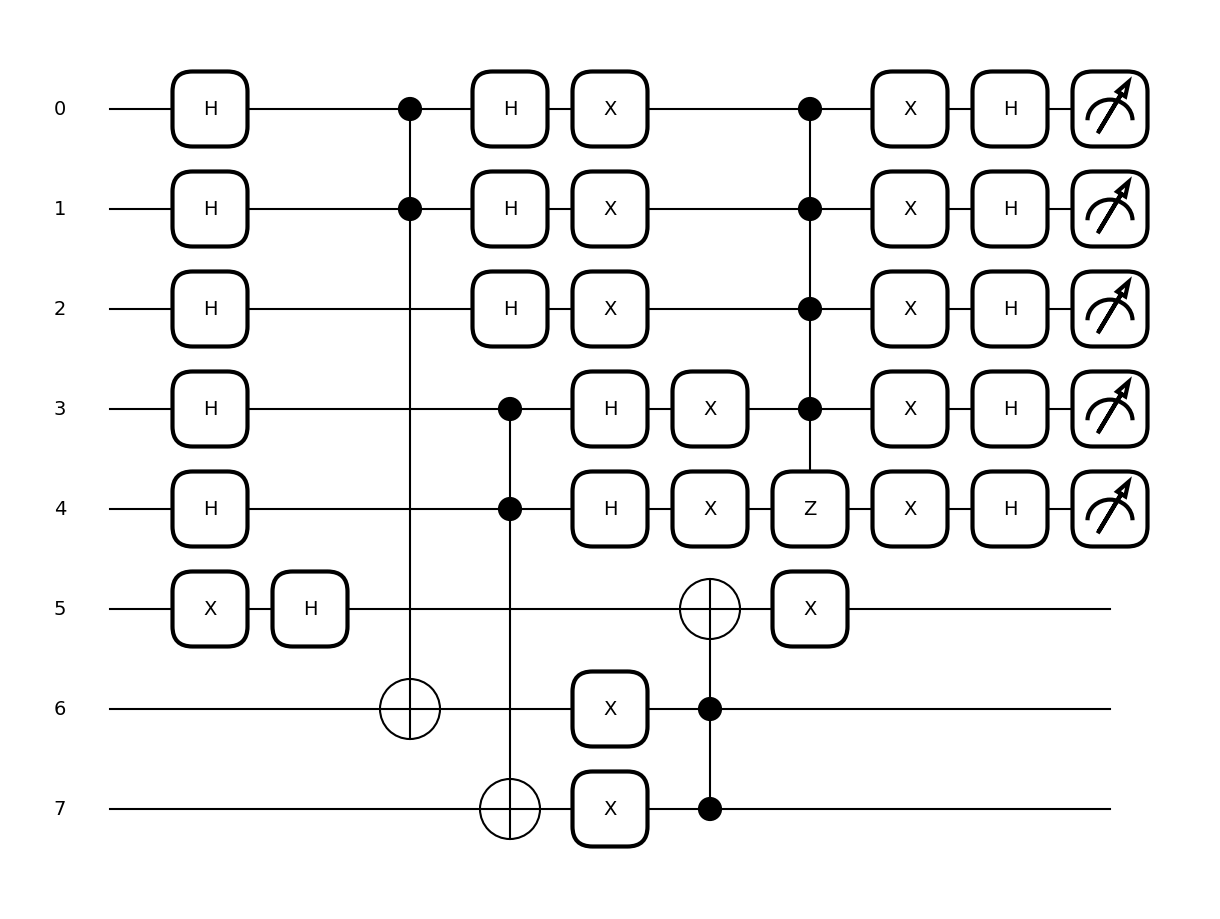

In [30]:

iterations = 1
qml.draw_mpl(grover_2qubits)(iterations)

In [31]:
p=grover_2qubits(iterations)
for i in range(2**(n_qubits-1)):
    print(f"|{i:0{n_qubits-1}b}>: {p[i]:.4f}")

|00000>: 0.0098
|00001>: 0.0098
|00010>: 0.0098
|00011>: 0.0566
|00100>: 0.0098
|00101>: 0.0098
|00110>: 0.0098
|00111>: 0.0566
|01000>: 0.0098
|01001>: 0.0098
|01010>: 0.0098
|01011>: 0.0566
|01100>: 0.0098
|01101>: 0.0098
|01110>: 0.0098
|01111>: 0.0566
|10000>: 0.0098
|10001>: 0.0098
|10010>: 0.0098
|10011>: 0.0566
|10100>: 0.0098
|10101>: 0.0098
|10110>: 0.0098
|10111>: 0.0566
|11000>: 0.0566
|11001>: 0.0566
|11010>: 0.0566
|11011>: 0.0723
|11100>: 0.0566
|11101>: 0.0566
|11110>: 0.0566
|11111>: 0.0723
